# Figure 1: Quench-And-Measure Protocol, Ryu-Takayanagi Formula, and (Entanglement) Entropy of Circle Boundary after Protocol

### Introduction

Figure 1 discusses the general scheme, discusses the Ryu-Takayanagi formula, and shows entanglement entropy vs. region size for a single circle boundary geometry generated from measuring the tree-and-crosslinks graph  (with zipper boundary conditions to make it a circle).

### Readability First

The goal of this notebook is to be clear and readable, so that members of group not directly involved in its coding can still understand it and provide feedback.

A bonus is that the author can also read the code well after it was written.

In [1]:
%load_ext autoreload
%autoreload 2

from __future__ import annotations

import loadconfig as loco
import matplotlib.pyplot as plt
import functions_for_A0_scaling as appendix_0
import matplotlib.gridspec as gridspec

import numpy as np

from graph2grav.figure_hashing import save_figure_with_hash

# Combined

Here  is the PRL advice on figures:


- Number figures with arabic numbers in the order in which they are referred to in the text.
- Supply a single caption that clearly summarizes the contents of the figure.
- Define figure symbols and curves either in a legend in the figure itself or in the caption.
- **Label subfigures (a), (b), etc., and include in the caption a description of each panel. If possible, submit figures with multiple panels as one file.**
- Size to **the width of a single manuscript column (8.5 cm or 3 3/8 in) or 1.5 or 2 columns for more detailed figures.** Ensure that content and details are readable at this size.
- Make the height of the smallest capital letters and numerals at least 2 mm and make the diameter of each data point at least 1 mm. Make a curve’s linewidth at least 0.18 mm (0.5 point). Avoid small open symbols, shading, and cross-hatching in figures.
- Label figure axes with the quantities plotted and **place units in parentheses** (not square brackets) after the quantity. See Axis Labels and Scales on Graphs for more information on how to style figure axes.
- **Use the Greek letter itself** rather than spelling out the name (e.g., use θ not \theta).
- Figures should accurately present the scientific results. **If adjustments to images, such as changing its brightness, are made, state the adjustment in the figure caption.**
  - **Note: we will have to be clear in the mutual information plot especially.**
- Please **use accessible color palettes for color figures.**


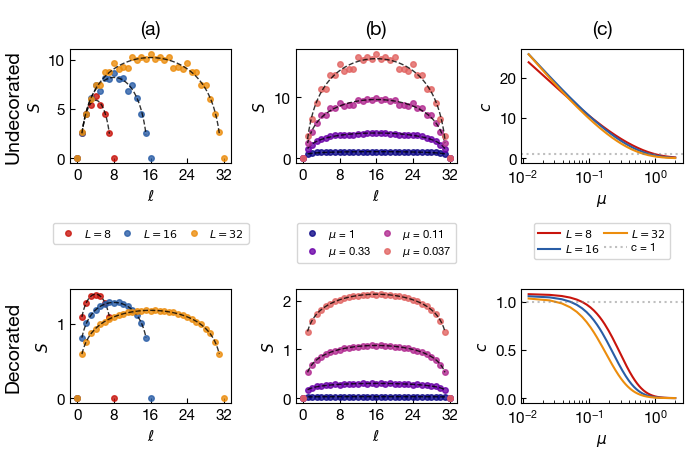

In [2]:
from matplotlib.transforms import Bbox

# (x0, y0, width, height) in INCHES of the figure
# bbox = Bbox.from_bounds(0.0, 0, 7.0, 5)

bottom_cut = 0.4
top_cut = 0
bbox = Bbox.from_bounds(0.0, bottom_cut, 7.0, 5.0 - bottom_cut - top_cut)

%config InlineBackend.print_figure_kwargs = {'bbox_inches': bbox}
%matplotlib inline


config = loco.reload()

# 1. Standard Setup
fig = plt.figure(figsize=(bbox.width, bbox.height + bottom_cut + top_cut)) # No layout engine needed

# 2. MASTER GRID (The 3 Columns)
# This controls the global margins and the gap BETWEEN the columns.
outer_gs = gridspec.GridSpec(2, 3, figure=fig, 
                             left=0.1, right=0.975, 
                             top=0.9, bottom=0.1, 
                             wspace=0.4, # Gap between the major columns
                             hspace=0.5, # Gap between rows
                             width_ratios=[1, 1, 1]) 

# 3. NESTED GRIDS (The Internals)

# --- Top Row: Undecorated ---
gs_left = gridspec.GridSpecFromSubplotSpec(
    2, 1, subplot_spec=outer_gs[0, 0],
    height_ratios=[1, 0.4], hspace=0)
ax_left = fig.add_subplot(gs_left[0])

gs_middle = gridspec.GridSpecFromSubplotSpec(
    2, 1, subplot_spec=outer_gs[0, 1],
    height_ratios=[1, 0.4], hspace=0)
ax_middle = fig.add_subplot(gs_middle[0])

gs_right = gridspec.GridSpecFromSubplotSpec(
    2, 1, subplot_spec=outer_gs[0, 2],
    height_ratios=[1, 0.4], hspace=0)
ax_right = fig.add_subplot(gs_right[0])

# --- Bottom Row: Decorated ---
gs_lower_left = gridspec.GridSpecFromSubplotSpec(
    2, 1, subplot_spec=outer_gs[1, 0],
    height_ratios=[1, 0.4], hspace=0)
ax_lower_left = fig.add_subplot(gs_lower_left[0])

gs_lower_middle = gridspec.GridSpecFromSubplotSpec(
    2, 1, subplot_spec=outer_gs[1, 1],
    height_ratios=[1, 0.4], hspace=0)
ax_lower_middle = fig.add_subplot(gs_lower_middle[0])

gs_lower_right = gridspec.GridSpecFromSubplotSpec(
    2, 1, subplot_spec=outer_gs[1, 2],
    height_ratios=[1, 0.4], hspace=0)
ax_lower_right = fig.add_subplot(gs_lower_right[0])


depths = [3, 4, 5]
squeezing_values = [1, 1/3, 1/9, 1/27]
squeezing_values_for_central_charge = np.linspace(1/81, 2, 150)


# --- Top Row: Undecorated ---
appendix_0.plot_entanglement_entropy_scaling_with_depth(ax_left, squeezing=1/10, depths=depths, config=config, is_decorated=False)
appendix_0.plot_entanglement_entropy_scaling_with_squeezing(ax_middle, squeezing_values=squeezing_values, config=config, is_decorated=False)
appendix_0.plot_central_charge_versus_squeezing(ax_right, squeezing_values=squeezing_values_for_central_charge, depths=depths, config=config, is_decorated=False)

# --- Bottom Row: Decorated ---
appendix_0.plot_entanglement_entropy_scaling_with_depth(ax_lower_left, squeezing=1/10, depths=depths, config=config, is_decorated=True)
appendix_0.plot_entanglement_entropy_scaling_with_squeezing(ax_lower_middle, squeezing_values=squeezing_values, config=config, is_decorated=True)
appendix_0.plot_central_charge_versus_squeezing(ax_lower_right, squeezing_values=squeezing_values_for_central_charge, depths=depths, config=config, is_decorated=True)

# --- Labels ---
ax_left.text(
    0.5, 1.1, "(a)",
    transform=ax_left.transAxes,
    ha="center", va="bottom",
    fontweight="bold",
    fontsize=14
)

ax_middle.text(
    0.5, 1.1, "(b)",
    transform=ax_middle.transAxes,
    ha="center", va="bottom",
    fontweight="bold",
    fontsize=14
)

ax_right.text(
    0.5, 1.1, "(c)",
    transform=ax_right.transAxes,
    ha="center", va="bottom",
    fontweight="bold",
    fontsize=14
)

# Write the word "Undecorated" and rotate it 90 degrees
ax_left.text(
    -0.35, 0.5, "Undecorated",
    transform=ax_left.transAxes,
    ha="center", va="center",
    fontweight="bold",
    fontsize=14,
    rotation=90
)

# Write the word "decorated" and rotate it 90 degrees
ax_lower_left.text(
    -0.35, 0.5, "Decorated",
    transform=ax_lower_left.transAxes,
    ha="center", va="center",
    fontweight="bold",
    fontsize=14,
    rotation=90
)

# --- Row titles ---
# ax_left.set_title("Undecorated", fontsize=10, fontweight="bold")
# ax_lower_left.set_title("Decorated", fontsize=10, fontweight="bold")

# --- Legends ---
ax_left.legend(fontsize=8, ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.5),
              columnspacing=0.4,
    handletextpad=0.4,
    borderaxespad=0.2,
    labelspacing=0.3 
               )
ax_middle.legend(fontsize=8, ncol=2, loc="upper center", bbox_to_anchor=(0.5, -0.5),
              columnspacing=0.4,
    handletextpad=0.4,
    borderaxespad=0.2,
    labelspacing=0.3
                 )
ax_right.legend(fontsize=8, ncol=2, loc="upper center", bbox_to_anchor=(0.5, -0.5),
              columnspacing=0.4,
    handletextpad=0.4,
    borderaxespad=0.2,
    labelspacing=0.3
                 )

# ax_lower_left.legend(fontsize=8, ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.3),
#               columnspacing=0.4,
#     handletextpad=0.4,
#     borderaxespad=0.2,
#     labelspacing=0.3 
#                )
# ax_lower_middle.legend(fontsize=8, ncol=2, loc="upper center", bbox_to_anchor=(0.5, -0.3),
#               columnspacing=0.4,
#     handletextpad=0.4,
#     borderaxespad=0.2,
#     labelspacing=0.3
#                  )

for ax in [ax_left, ax_middle, ax_lower_left, ax_lower_middle]:
    ax.set_xticks([0, 8, 16, 24, 32])


if export_figure := True:
    save_figure_with_hash(fig, "figures/supp_0_scaling.pdf", bbox_inches=bbox)